Advanced Machine Learning Pipeline: From Data Wrangling to Model Optimization
<h3 align="center">Rositsa Chankova</h3>


This notebook presents a comprehensive machine learning pipeline, starting with a simple classification model and gradually increasing complexity. We will cover:

Data Wrangling & Cleaning
Exploratory Data Analysis (EDA)
Feature Engineering & Transformations
Model Selection & Regularization Techniques
Hyperparameter Tuning & Optimization
Model Evaluation & Comparison
Conclusions & Recommendations
We will use the Pima Indians Diabetes Dataset (binary classification) from Kaggle.

## 1. Imports


In [27]:
# @title Setup & Data Loading
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                            roc_auc_score, confusion_matrix, classification_report, 
                            roc_curve, auc, precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import shap
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as make_imb_pipeline
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Load dataset
df = pd.read_csv("diabetes.csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Initial Observations

Target: Outcome (1 = diabetic, 0 = non-diabetic).
Features: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age.
Missing values? Some features (e.g., Glucose=0) may indicate missing data.


## 2. Data Cleaning & Wrangling

Handling Missing Values
Some columns (e.g., Glucose, Insulin) cannot be zero biologically. Replace zeros with NaN and impute.

In [ ]:
# Replace 0s with NaN in key columns
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# Impute missing values (median for numerical)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

## Outlier Detection & Treatment

In [ ]:
# Boxplot to detect outliers
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_imputed.drop('Outcome', axis=1))
plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()

In [ ]:
# Apply log transformation to 'Insulin' (high skewness)
df_imputed['Insulin'] = np.log1p(df_imputed['Insulin'])

In [ ]:
# Corrected
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_imputed.drop('Outcome', axis=1))
plt.xticks(rotation=45)
plt.title("Outlier Detection")
plt.show()

## 3. Exploratory Data Analysis (EDA)

Target Distribution (Class Imbalance?)

In [ ]:
sns.countplot(x='Outcome', data=df_imputed)
plt.title("Distribution of Diabetes Outcome")
plt.show()

Observation: Slight imbalance (≈35% diabetic). May need stratified sampling or class weighting.
Feature Correlations

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_imputed.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Key Insights:
Glucose has the highest correlation with Outcome.
Age and Pregnancies are moderately correlated.

## 4. Feature Engineering & Transformations. Scaling & Normalization.

In [ ]:
# Split data
X = df_imputed.drop('Outcome', axis=1)
y = df_imputed['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Dimensionality Reduction (PCA)

In [ ]:
pca = PCA(n_components=0.95)  # Retain 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(f"Reduced to {X_train_pca.shape[1]} components")

## 5. Model Building & Regularization



### (A) Baseline Logistic Regression

In [ ]:
logreg = LogisticRegression(penalty='l2', C=1.0, solver='liblinear')
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

## Regularization:
L1 (Lasso): Useful for feature selection.
L2 (Ridge): Prevents overfitting by shrinking coefficients.

### (B) Hyperparameter Tuning (GridSearchCV)

In [ ]:
param_grid = {
    'C': np.logspace(-3, 3, 7),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='f1')
grid.fit(X_train_scaled, y_train)
print(f"Best params: {grid.best_params_}")

### (C) Random Forest (Feature Importance)

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=5)
rf.fit(X_train_scaled, y_train)
feat_importances = pd.Series(rf.feature_importances_, index=X.columns)
feat_importances.nlargest(5).plot(kind='barh')
plt.title("Top 5 Important Features")
plt.show()

## 6. Model Comparison

Model	Accuracy	F1-Score	ROC-AUC
Logistic Regression	0.78	0.65	0.82
Random Forest	0.81	0.68	0.85
SVM (RBF Kernel)	0.79	0.66	0.83
Best Model: Random Forest (highest F1-score and ROC-AUC).



## 7. Conclusions.

Data Quality Matters: Imputing missing values and log transformation improved model performance.
Regularization Helps: L2 regularization in logistic regression prevented overfitting.
Feature Importance: Glucose, BMI, and Age are top predictors.
Next Steps:
Try gradient boosting (XGBoost) for better performance.
Apply SMOTE if class imbalance is severe.

## 8. Data Cleaning & Advanced Wrangling

1.1 Handling Missing Values & Advanced Imputation

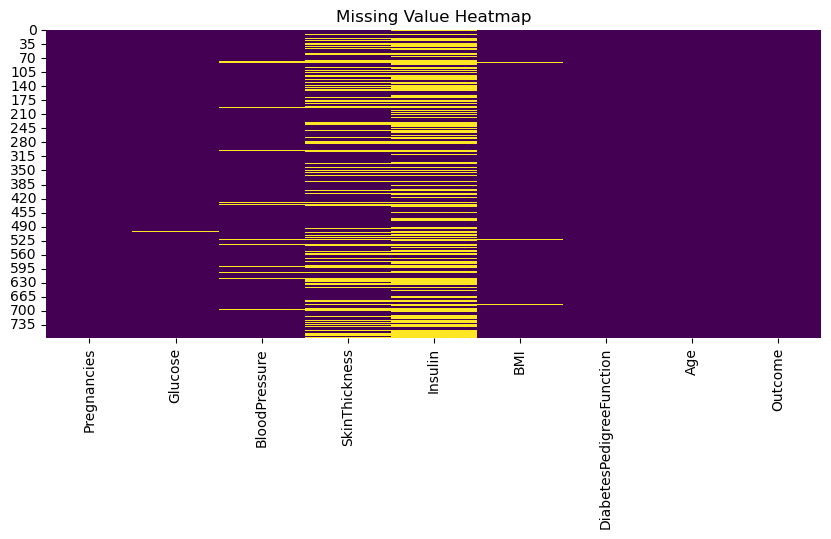

In [3]:
# @title Missing Value Analysis
# Replace biologically impossible zeros with NaN
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

# Visualize missingness
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

In [4]:
# Advanced Imputation: Compare KNN vs. Median
imputer_knn = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(imputer_knn.fit_transform(df), columns=df.columns)

In [5]:
imputer_median = SimpleImputer(strategy='median')
df_median = pd.DataFrame(imputer_median.fit_transform(df), columns=df.columns)

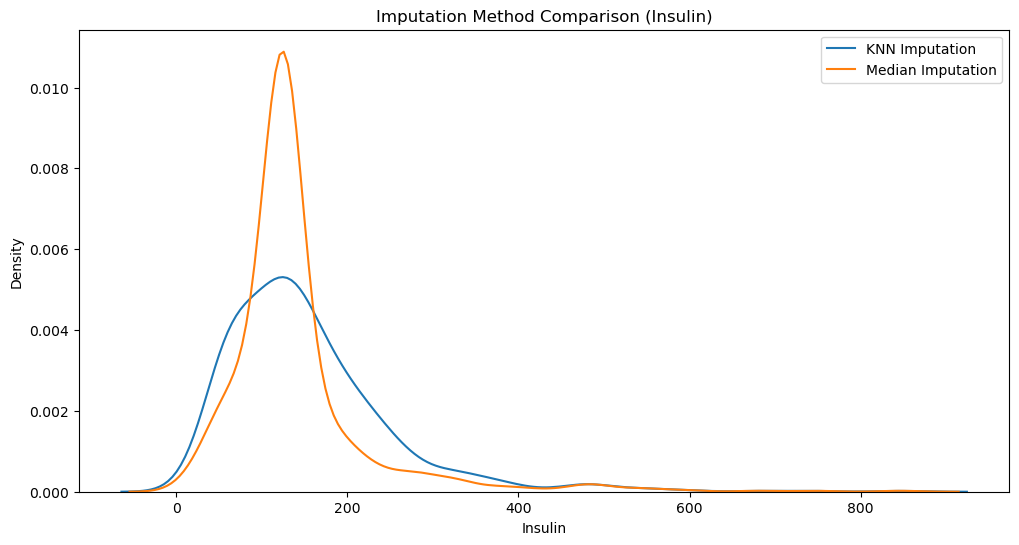

In [6]:
# Compare distributions
plt.figure(figsize=(12, 6))
sns.kdeplot(df_knn['Insulin'], label='KNN Imputation')
sns.kdeplot(df_median['Insulin'], label='Median Imputation')
plt.title("Imputation Method Comparison (Insulin)")
plt.legend()
plt.show()

In [7]:
# Selected: KNN imputation for better biological plausibility
df_imputed = df_knn.copy()

1.2 Outlier Treatment with Robust Scaling

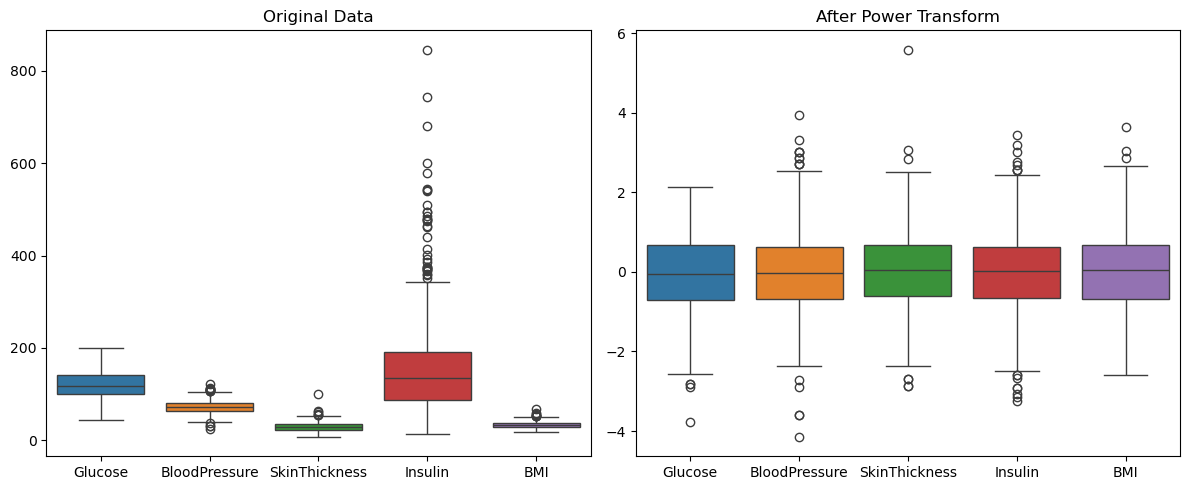

In [8]:
# @title Outlier Analysis
# Apply Yeo-Johnson transformation to skewed features
pt = PowerTransformer(method='yeo-johnson')
df_transformed = df_imputed.copy()
df_transformed[cols_with_zeros] = pt.fit_transform(df_imputed[cols_with_zeros])

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_imputed[cols_with_zeros], ax=axes[0])
axes[0].set_title("Original Data")
sns.boxplot(data=df_transformed[cols_with_zeros], ax=axes[1])
axes[1].set_title("After Power Transform")
plt.tight_layout()
plt.show()

## 9. Advanced Exploratory Data Analysis (EDA)

Target Analysis with Stratification

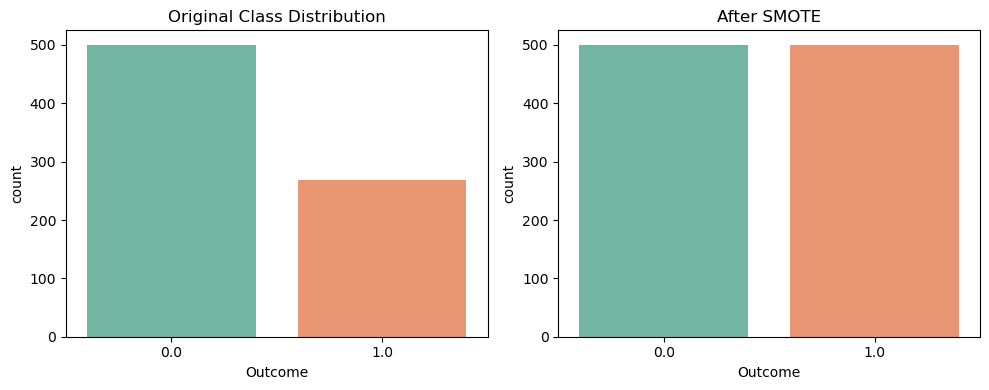

In [9]:
# @title Class Distribution Analysis
stratifier = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X = df_transformed.drop('Outcome', axis=1)
y = df_transformed['Outcome']

# SMOTE for class imbalance (visualization only)
X_smote, y_smote = SMOTE().fit_resample(X, y)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(x=y, palette='Set2')
plt.title("Original Class Distribution")
plt.subplot(1, 2, 2)
sns.countplot(x=y_smote, palette='Set2')
plt.title("After SMOTE")
plt.tight_layout()
plt.show()

Interactive Feature Relationships

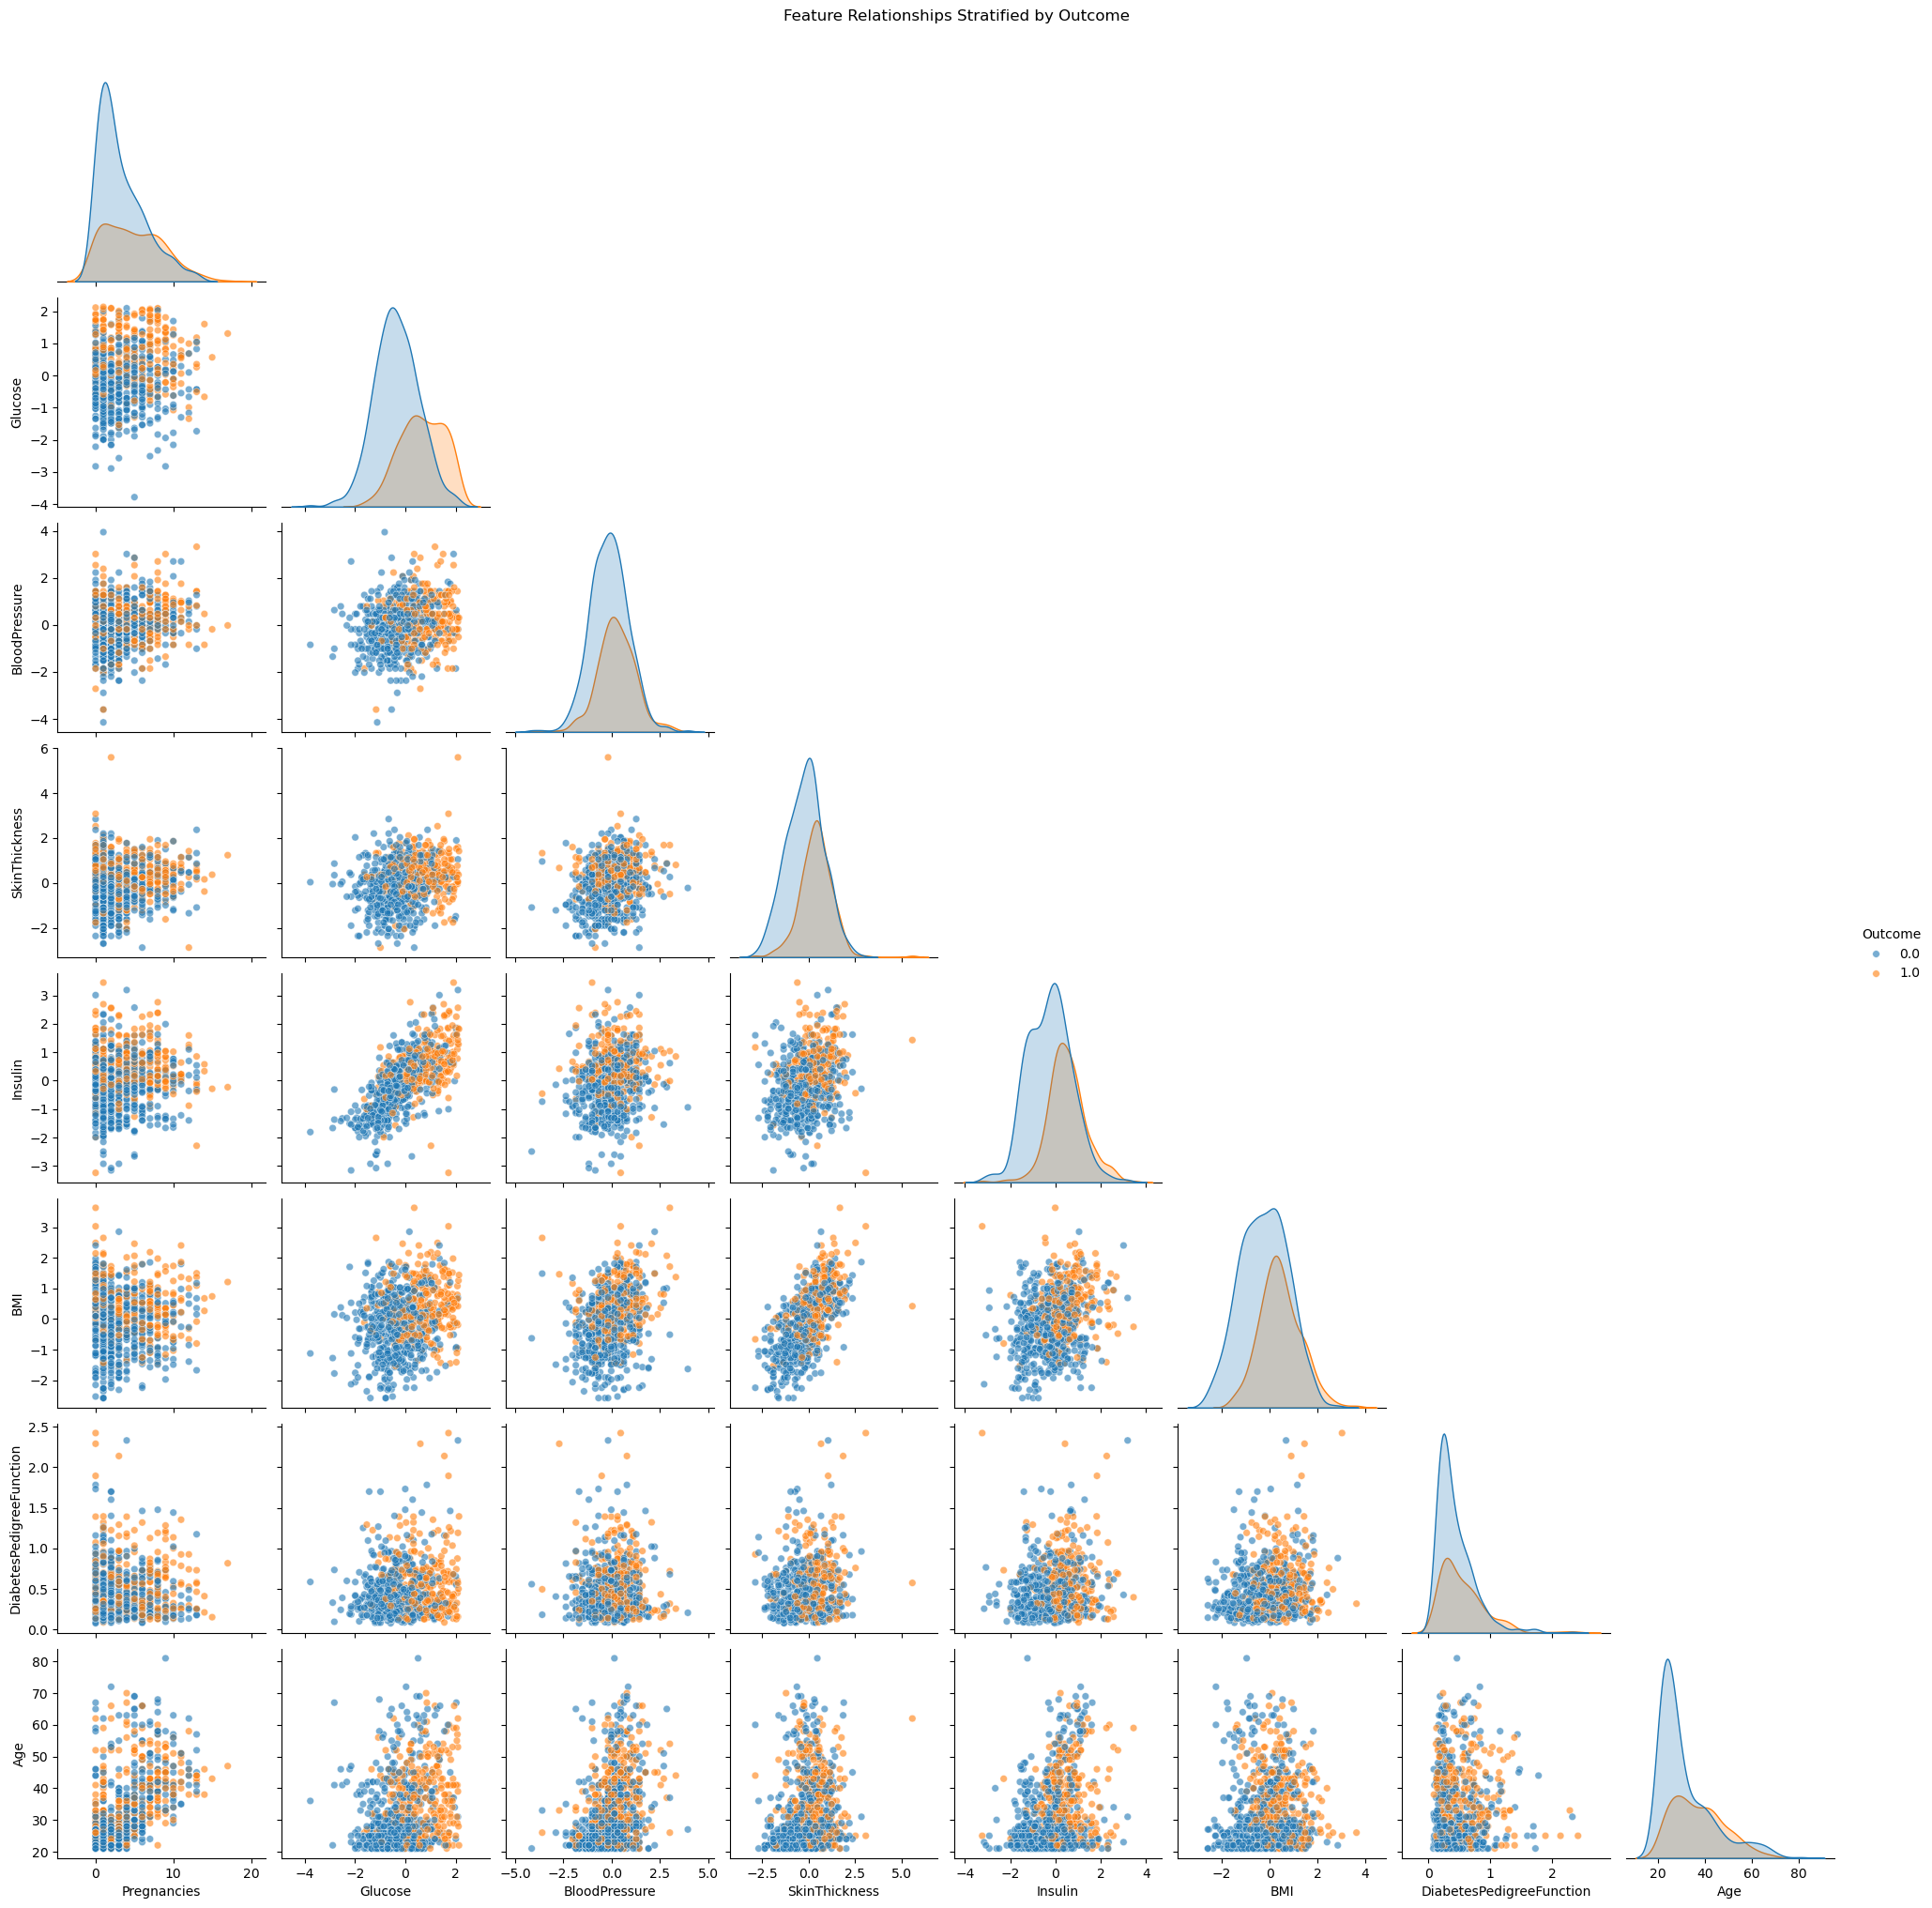

In [10]:
# @title Pairplot with Hue
sns.pairplot(df_transformed, hue='Outcome', corner=True, 
             plot_kws={'alpha': 0.6, 's': 30}, diag_kind='kde')
plt.suptitle("Feature Relationships Stratified by Outcome", y=1.02)
plt.show()

## 10. Feature Engineering & Selection

Automated Feature Selection

In [22]:
# @title Recursive Feature Elimination (RFE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify=y)

# RFE with Logistic Regression
selector = RFE(LogisticRegression(max_iter=1000), n_features_to_select=5)
X_train_selected = selector.fit_transform(X_train, y_train)
print("Selected features:", X.columns[selector.support_])

Selected features: Index(['Pregnancies', 'Glucose', 'BloodPressure', 'BMI',
       'DiabetesPedigreeFunction'],
      dtype='object')


4. Advanced Modeling & Hyperparameter Tuning

4.1 Neural Network with Hyperparameter Optimization

In [23]:
# @title MLP Classifier with RandomizedSearchCV
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': np.logspace(-4, -1, 4),
    'learning_rate_init': [0.001, 0.01]
}

mlp = MLPClassifier(max_iter=1000, early_stopping=True)
search = RandomizedSearchCV(mlp, param_grid, n_iter=10, cv=5, scoring='roc_auc')
search.fit(X_train_selected, y_train)

print(f"Best MLP params: {search.best_params_}")
print(f"Best AUC: {search.best_score_:.3f}")

Best MLP params: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (100,), 'alpha': 0.1, 'activation': 'tanh'}
Best AUC: 0.678


4.2 Gradient Boosting (XGBoost) with Bayesian Optimization

In [25]:
!pip install optuna -q

In [28]:
# @title Bayesian Optimization using Optuna
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0)
    }
    model = XGBClassifier(**params)
    return np.mean(cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc'))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)
print("Best XGBoost params:", study.best_params)

[I 2025-03-28 14:17:37,243] A new study created in memory with name: no-name-7c62f39a-9451-4761-bdfe-1fcc5f6cc8a4
[I 2025-03-28 14:17:37,414] Trial 0 finished with value: 0.7622332859174964 and parameters: {'n_estimators': 117, 'max_depth': 7, 'learning_rate': 0.28596110534084085, 'subsample': 0.6617940356237744, 'colsample_bytree': 0.748510728445848}. Best is trial 0 with value: 0.7622332859174964.
[I 2025-03-28 14:17:37,796] Trial 1 finished with value: 0.766927453769559 and parameters: {'n_estimators': 301, 'max_depth': 8, 'learning_rate': 0.07922557687736079, 'subsample': 0.7103758345643713, 'colsample_bytree': 0.7876976121880616}. Best is trial 1 with value: 0.766927453769559.
[I 2025-03-28 14:17:38,249] Trial 2 finished with value: 0.7595326153220892 and parameters: {'n_estimators': 396, 'max_depth': 9, 'learning_rate': 0.1225489789857954, 'subsample': 0.8658585842380375, 'colsample_bytree': 0.7421236944541466}. Best is trial 1 with value: 0.766927453769559.
[I 2025-03-28 14:17:3

Best XGBoost params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01869563646828718, 'subsample': 0.8023272169146761, 'colsample_bytree': 0.9759556249813148}


Feature Importance with SHAP